# Understanding the exclusion regions

**Private.** Pedagogical companion to
[`01_limit_contour.ipynb`](01_limit_contour.ipynb) — it explains *why* the
excluded region has the shape it does, edge by edge. Nothing here feeds the
limit. Mode-aware via `MODE_NUMBER` (same inputs as notebook 01); the scalings
below are mode-independent.

In [1]:
# ===== CONFIG: which sensor mode this notebook analyses =====
MODE_NUMBER = 1   # 1, 2, or 3

%matplotlib inline
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from luhdm import config, units
from luhdm import release
rel = release.open_release()

R_eff = config.R_EFF             # 200 um
Q_THRESH = config.Q_THRESH       # GeV
T_TOTAL = config.T_EXPOSURE      # dataset live-time, 469.7 h (single source of truth)
CONFIDENCE = 0.95
M_PLANCK = 1.22e19               # GeV

# the seven planned mediator ranges, largest first. The family is ordered in
# lambda, so it gets a sequential blue-to-green ramp (truncated viridis:
# monotone lightness survives black-and-white printing and is colorblind-safe,
# and it contains no red, which is reserved for the events / 95% contour).
_TAGS = ["2m", "2cm", "2mm", "200um", "20um", "10um", "2um"]
_LAMBS = [2.0, 2e-2, 2e-3, 2e-4, 2e-5, 1e-5, 2e-6]
_RAMP = plt.cm.viridis(np.linspace(0.02, 0.78, len(_TAGS)))
LAMBDAS = list(zip(_TAGS, _LAMBS, [tuple(c) for c in _RAMP]))
HIDE = {"2um"}                   # loaded and exported, but not drawn
LAMB_REF = 2e-4                  # reference range for the detailed figures

def lamb_label(lamb_m):
    # mediator range in SI and natural units, for plot labels
    x = units.conv_m2pGeV(lamb_m)
    e = int(np.floor(np.log10(x)))
    if lamb_m >= 1:
        si = f"{lamb_m:.0f} m"
    elif lamb_m >= 1e-2:
        si = f"{lamb_m * 1e2:.0f} cm"
    elif lamb_m >= 1e-3:
        si = f"{lamb_m * 1e3:.0f} mm"
    else:
        si = f"{lamb_m * 1e6:.3g} µm"
    return rf"$\lambda$ = {si}"


def mphi_label(lamb_m, unit="eV"):
    # mediator mass m_phi = hbar c / lambda
    m_phi = 1.0 / units.conv_m2pGeV(lamb_m)
    if unit == "eV":
        m_phi *= 1e9
    e = int(np.floor(np.log10(m_phi)))
    return rf"$m_\phi$ = ${m_phi / 10**e:.1f}\times10^{{{e}}}$ {unit}"


def range_legend(lamb_m):
    # legend entry: range and the corresponding mediator mass (in eV)
    return lamb_label(lamb_m).split(" = $")[0] + ", " + mphi_label(lamb_m)


# SI-prefix milestones on a DM-mass axis (masses in GeV; names in eV prefixes)
MASS_MILESTONES = [(1e6, "PeV"), (1e9, "EeV"), (1e12, "ZeV"), (1e15, "YeV")]

def mark_mass_milestones(ax, m_lo, m_hi):
    import matplotlib.patheffects as _pe
    for m_gev, name in MASS_MILESTONES:
        if m_lo < m_gev < m_hi:
            ax.axvline(m_gev, color="#7f7f7f", lw=1.0, ls="-.", zorder=1)
            txt = ax.text(m_gev, 0.015, f" {name}", color="#555555",
                          fontsize=9, ha="left", va="bottom", rotation=90,
                          transform=ax.get_xaxis_transform())
            txt.set_path_effects([_pe.Stroke(linewidth=2.2, foreground="w"),
                                  _pe.Normal()])


import os as _os
for _d in ("png", "svg", "pdf"):
    _os.makedirs(_d, exist_ok=True)

def save_figure(fig, name, **kw):
    # every figure lands in png/, svg/, and pdf/ with a notebook-number prefix
    for ext in ("png", "svg", "pdf"):
        fig.savefig(f"{ext}/{name}.{ext}", dpi=140, **kw)


print(f"N_n = {config.N_NEUTRONS:.2e}   q_th = {Q_THRESH:.0f} GeV   "
      f"R_eff = {R_eff * 1e6:.0f} um   f_X = {config.F_X}")

N_n = 2.51e+20   q_th = 100 GeV   R_eff = 200 um   f_X = 0.1


In [2]:
# Observed impulse candidates for this mode (GeV), from the data release.
# Kept only for label counts; nothing here feeds the maps below.
EVENTS = rel.events(MODE_NUMBER)
print(f"observed kicks [GeV]: {np.round(EVENTS, 1)}")

observed kicks [GeV]: [   861.     947.6   1245.8   1305.    1339.1   1348.2   1377.3   1443.1
   1461.    1478.9   1486.3   1520.7   1544.4   1615.5   1629.    1659.9
   1661.3   1678.5   1729.4   1733.5   1761.1   1795.1   1814.2   1842.3
   1872.7   2013.4   2018.3   2021.5   2033.7   2037.5   2055.5   2092.5
   2137.1   2147.5   2215.6   2245.    2366.2   2467.8   2508.7   2527.9
   2575.3   2611.2   2716.3   2842.9   2862.    2969.8   2987.9   3235.9
   3252.4   3338.4   3509.6   5705.1   6749.    6761.9   6905.1   6913.2
   6979.5   9482.1  12790.7  18563.1  18622.2  25153.3  38608.5  78392.1
 113305.8 126524.3]


In [3]:
# The two exclusion planes overlaid on the maps below: the massless (Coulomb)
# scan and the finite reference-range (200 um) scan, sliced from the data release.
P_ML = rel.mass_plane("extremeness", MODE_NUMBER, "massless")
P_REF = rel.mass_plane("extremeness", MODE_NUMBER, "200um")

## Understanding the edges

*Everything in this section is pedagogical; none of it feeds the limit.* Every
edge of the excluded region has a one-line explanation (scalings at fixed
exposure):

- **Left edge (kinematic floor).** Below
  $m \approx q_\text{th}/v_\text{esc} \approx 5\times10^{4}$ GeV even an
  escape-velocity particle cannot deliver the threshold kick, at any coupling
  ($q_\text{th}$ = 0.1 TeV/$c$, $v_\text{esc} = 1.8\times10^{-3}$). The scan grid
  starts just above this wall.
- **Bottom edge (statistics floor).** The smallest coupling with $\mu \gtrsim 3$
  expected events. The rate scales as $\alpha^2 n_\text{DM} \propto \alpha^2/m$,
  so the floor rises as $\alpha_\text{min} \propto \sqrt{m}$. Ranges with
  $\lambda \gtrsim$ mm share the same floor (Coulomb regime); shorter ranges pay
  the momentum-cap penalty, $\tilde q_\text{max} = K_1(\xi)$.
- **Top edge (atmospheric ceiling).** Stopping power also scales as $\alpha^2/m$:
  above the ceiling particles arrive below threshold speed, so the ceiling rises
  $\propto \sqrt{m}$ (up to a Coulomb log).
- **Right edge (reach saturation).** Once the impact parameters needed for a kick
  exceed $\lambda$, the reach grows only as $\lambda\ln\alpha$, the cross section
  saturates at $\sim\lambda^2$, and the falling number density $1/m$ wins: each
  factor of 10 in $\lambda$ buys roughly a factor of 100 in mass reach. No finite
  range reaches the Planck mass; only an exactly massless mediator (Coulomb reach
  $\propto \alpha$, unbounded) keeps the band open, as the maps below show.

The maps below make these statements visible for the reference range.

### Transit-count and reach maps up to the Planck mass

These maps are supplemental backup material; they are sliced from the `/halo`
group of the data release.

**Top row:** color is $\log_{10} N_t$, the expected number of particles passing
within $\pi b_\text{max}^2$ during the exposure (halo flux, no attenuation;
the atmosphere only matters near the low-mass ceiling). White contours mark
decades of $N_t$ (the $N_t = 1$ line is drawn heavier); red: the 95% exclusion
contour from the scan. The
finite-range $N_t = 1$ boundary is a near-vertical wall (saturating reach);
a truly massless mediator's boundary is a $\sqrt{m}$ diagonal that continues
to the Planck mass.

**Bottom row:** the flux-averaged threshold reach
$b_\text{max} = \sqrt{\langle b^2 \rangle}$ in meters, with contours at
everyday length scales and the same red 95% exclusion contour overlaid, so
the reach along the sensitivity boundary can be read off directly. This is the aperture that converts flux into transits,
$N_t = \Phi \cdot \pi b_\text{max}^2 \cdot T$: for the massless mediator the
*formal* reach at large coupling is macroscopic
($b_\text{max} = 2\alpha/(q_\text{th} v)$), so flux quantization alone never
closes the band; the finite-range reach saturates near
$R_\text{eff} + \mathcal{O}(10)\lambda$, which is why its $N_t = 1$ wall is
real. Capping the massless reach at a laboratory scale $b_\text{cap}$ would
turn the falling flux into a hard, coupling-independent endpoint at
$m_\text{end} = \rho\,\bar v\,\pi b_\text{cap}^2\,T \approx
3.5\times10^{15}\ \text{GeV} \times (b_\text{cap}/10\,\text{cm})^2\,
(T/470\,\text{h})$.


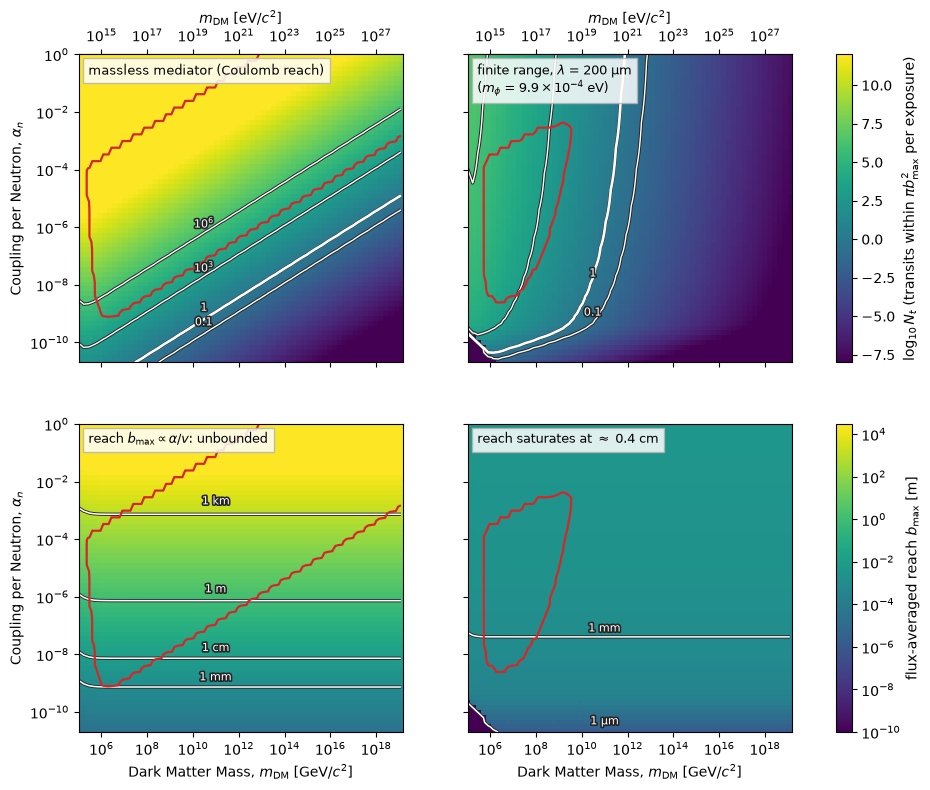

In [4]:
# transit-count and reach maps, sliced from the /halo group of the data release
ms_map, al_map = rel.axes_halo.mass_gev, rel.axes_halo.alpha_n
NT_ML_MAP = rel.mass_plane("n_transit", lam="massless", group="halo")
B_ML_MAP = rel.mass_plane("bmax", lam="massless", group="halo")
NT_FR_MAP = rel.mass_plane("n_transit", lam="200um", group="halo")
B_FR_MAP = rel.mass_plane("bmax", lam="200um", group="halo")

import matplotlib.patheffects as pe
from matplotlib.colors import LogNorm, Normalize

def outline(artists):  # keep white lines/labels legible on any viridis shade
    for a in artists:
        a.set_path_effects([pe.Stroke(linewidth=2.4, foreground="0.15"),
                            pe.Normal()])

def label_levels(ax, X_MAP, levels, names, m_ref=1e11):
    # label each level just above its line, mid-plot (the lines are close to
    # horizontal away from the kinematic floor)
    col = np.argmin(np.abs(ms_map - m_ref))
    for lev in levels:
        with np.errstate(divide="ignore"):
            miss = np.abs(np.log10(np.where(X_MAP[:, col] > 0,
                                            X_MAP[:, col], np.nan) / lev))
        if np.nanmin(miss) < 0.3:
            y = al_map[np.nanargmin(miss)]
            txt = ax.text(m_ref, y * 1.5, names[lev], fontsize=8, color="w",
                          ha="center", va="bottom")
            outline([txt])

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.8), sharex=True, sharey=True)
norm_nt = Normalize(vmin=-8, vmax=12)
norm_b = LogNorm(vmin=1e-10, vmax=3e4)
NT_LEVELS = [0.1, 1.0, 1e3, 1e6]
NT_NAMES = {0.1: "0.1", 1.0: "1", 1e3: "$10^3$", 1e6: "$10^6$"}
B_LEVELS = [1e-6, 1e-3, 1e-2, 1.0, 1e3]
B_NAMES = {1e-6: "1 µm", 1e-3: "1 mm", 1e-2: "1 cm", 1.0: "1 m", 1e3: "1 km"}
titles = ["massless mediator (Coulomb reach)",
          "finite range, " + lamb_label(LAMB_REF) + "\n(" +
          mphi_label(LAMB_REF) + ")"]

for j, (NT_MAP, B_MAP) in enumerate([(NT_ML_MAP, B_ML_MAP),
                                     (NT_FR_MAP, B_FR_MAP)]):
    ax = axes[0, j]
    z = np.log10(np.clip(NT_MAP, 1e-8, 1e12))
    mesh_nt = ax.pcolormesh(ms_map, al_map, z, cmap="viridis", norm=norm_nt,
                            shading="auto")
    cs = ax.contour(ms_map, al_map, NT_MAP, levels=NT_LEVELS, colors="w",
                    linewidths=[1.0 if lev != 1.0 else 1.9
                                for lev in NT_LEVELS])
    outline(getattr(cs, "collections", [cs]))
    label_levels(ax, NT_MAP, NT_LEVELS, NT_NAMES, m_ref=3e10)
    ax.text(0.03, 0.97, titles[j], transform=ax.transAxes, ha="left",
            va="top", fontsize=9, bbox=dict(fc="white", ec="0.7", alpha=0.85))

    ax = axes[1, j]
    mesh_b = ax.pcolormesh(ms_map, al_map, np.clip(B_MAP, 1e-10, None),
                           cmap="viridis", norm=norm_b, shading="auto")
    cs = ax.contour(ms_map, al_map, B_MAP, levels=B_LEVELS, colors="w",
                    linewidths=1.1)
    outline(getattr(cs, "collections", [cs]))
    label_levels(ax, B_MAP, B_LEVELS, B_NAMES)
    note = (r"reach $b_{\rm max} \propto \alpha/v$: unbounded" if j == 0 else
            rf"reach saturates at $\approx$ {B_MAP.max() * 100:.1f} cm")
    ax.text(0.03, 0.97, note, transform=ax.transAxes, ha="left",
            va="top", fontsize=9, bbox=dict(fc="white", ec="0.7", alpha=0.85))
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV/$c^2$]")

# overlay each column's own 95% exclusion: the massless (Coulomb) scan on the
# massless panels, the finite reference-range scan on the finite-range panels
COL_SCAN = [dict(ms=rel.axes.mass_gev, alphas_n=rel.axes.alpha_n, extremeness=P_ML),
            dict(ms=rel.axes.mass_gev, alphas_n=rel.axes.alpha_n, extremeness=P_REF)]   # j=0 massless, j=1 finite (200um)
for i in (0, 1):
    for j in (0, 1):
        s = COL_SCAN[j]
        if s is None:
            continue
        axes[i, j].contour(s["ms"], s["alphas_n"], s["extremeness"],
                           levels=[CONFIDENCE], colors="#d62728",
                           linewidths=1.6)

for ax in axes[:, 0]:
    ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
axes[0, 0].set_ylim(al_map[0], 1.0)
for j in (0, 1):
    sec = axes[0, j].secondary_xaxis(
        "top", functions=(lambda x: x * 1e9, lambda x: x / 1e9))
    sec.set_xlabel(r"$m_{\rm DM}$ [eV/$c^2$]")
fig.colorbar(mesh_nt, ax=axes[0, :], label=r"$\log_{10} N_t$ (transits within "
                                           r"$\pi b_{\rm max}^2$ per exposure)")
fig.colorbar(mesh_b, ax=axes[1, :],
             label=r"flux-averaged reach $b_{\rm max}$ [m]")
save_figure(fig, "03_transit_reach_maps", bbox_inches="tight")

## Further reading

- Monteiro et al., PRL 125, 181102 ([arXiv:2007.12067](https://arxiv.org/abs/2007.12067)):
  the massless-mediator behavior (open band, no high-mass endpoint).
- The public tutorial
  [`uhdm_finite_range.ipynb`](https://github.com/tunnell/optimum_interval/blob/master/examples/uhdm_finite_range.ipynb):
  the same seven ranges in vacuum with a five-candidate toy dataset; comparing
  the two shows what the atmosphere does to each channel.
